# Task 05 — Time-Series Forecasting with ARIMA & Prophet

**End-to-End Demand Forecasting Pipeline: Trend, Seasonality, Stationarity, Model Training & 30-Day Projections**

This notebook implements an end-to-end time-series analysis and forecasting pipeline for daily product demand, evaluating classical Box-Jenkins (SARIMAX) and additive Bayesian (Facebook Prophet) architectures.

## 1. Objectives & Pipeline Workflow

1. **Exploratory Data Analysis**: Inspect historical demand dynamics, rolling trends, and variance.
2. **Classical & STL Decomposition**: Decompose demand into Trend ($T_t$), Seasonality ($S_t$), and Residual ($R_t$) components.
3. **Stationarity Analysis**: Conduct the Augmented Dickey-Fuller (ADF) test, apply differencing, and analyze ACF/PACF correlograms.
4. **Model Training & Hyperparameter Tuning**:
   - Grid search optimal SARIMA/SARIMAX $(p,d,q) \times (P,D,Q)_s$ orders using AIC.
   - Fit Facebook Prophet with weekly seasonality and exogenous event regressors.
5. **Out-of-Sample Evaluation**: Evaluate models on a 30-day holdout split using RMSE, MAE, and MAPE.
6. **Future Projections**: Generate 30-day forward forecast projections with 95% confidence intervals.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from prophet import Prophet

# Configure plot styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load and Inspect Daily Demand Dataset

The dataset tracks historical daily product demand along with exogenous indicators:
- `date`: Observation date
- `demand`: Total units demanded
- `marketing_event`: Binary indicator (1 if marketing campaign active, 0 otherwise)
- `holiday`: Binary indicator (1 if official holiday, 0 otherwise)

In [2]:
data_path = 'data/daily_demand.csv'
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df.set_index('date', inplace=True)

print(f'Total observations: {len(df)}')
print(f'Date range: {df.index.min().strftime("%Y-%m-%d")} to {df.index.max().strftime("%Y-%m-%d")}')
print('\nSummary Statistics:')
print(df.describe().round(2))
print('\nMissing values:\n', df.isnull().sum())

Total observations: 365
Date range: 2025-07-01 to 2026-06-30

Summary Statistics:
       demand  marketing_event  holiday
count  365.00           365.00   365.00
mean    95.45             0.26     0.13
std     28.21             0.44     0.34
min     41.00             0.00     0.00
25%     73.00             0.00     0.00
50%     95.00             0.00     0.00
75%    115.00             1.00     0.00
max    174.00             1.00     1.00

Missing values:
 demand             0
marketing_event    0
holiday            0
dtype: int64


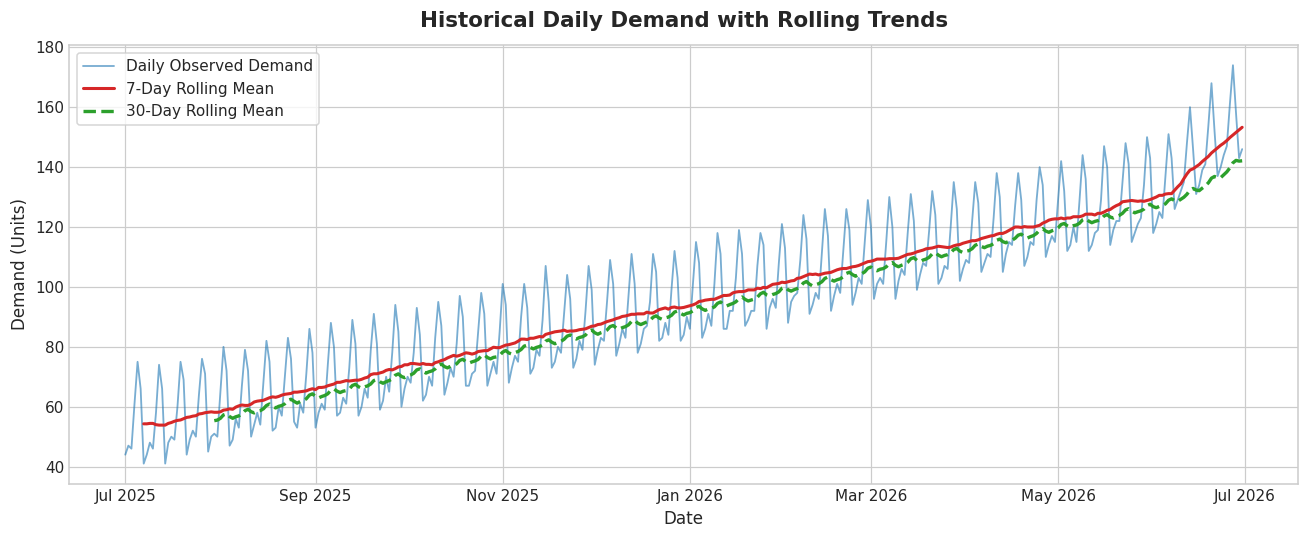

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df['demand'], label='Daily Observed Demand', color='#1f77b4', alpha=0.6, lw=1.2)
ax.plot(df.index, df['demand'].rolling(7).mean(), label='7-Day Rolling Mean', color='#d62728', lw=2)
ax.plot(df.index, df['demand'].rolling(30).mean(), label='30-Day Rolling Mean', color='#2ca02c', lw=2.2, ls='--')

ax.set_title('Historical Daily Demand with Rolling Trends', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Demand (Units)', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## 3. Time Series Decomposition

Time series decomposition separates the observed demand $Y_t$ into fundamental orthogonal components:
$$
Y_t = T_t + S_t + R_t
$$
where:
- $T_t$ represents the deterministic underlying **Trend**.
- $S_t$ represents the repeating **Weekly Seasonality** ($m = 7$).
- $R_t$ represents the irregular **Residuals** (noise).

In [4]:
decomposition = seasonal_decompose(df['demand'], model='additive', period=7)
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

print('Decomposition completed.')
print(f'Seasonal amplitude (peak to trough): {seasonal.max() - seasonal.min():.2f} units')
print(f'Residual standard deviation: {residual.dropna().std():.2f} units')

Decomposition completed.
Seasonal amplitude (peak to trough): 32.17 units
Residual standard deviation: 1.25 units


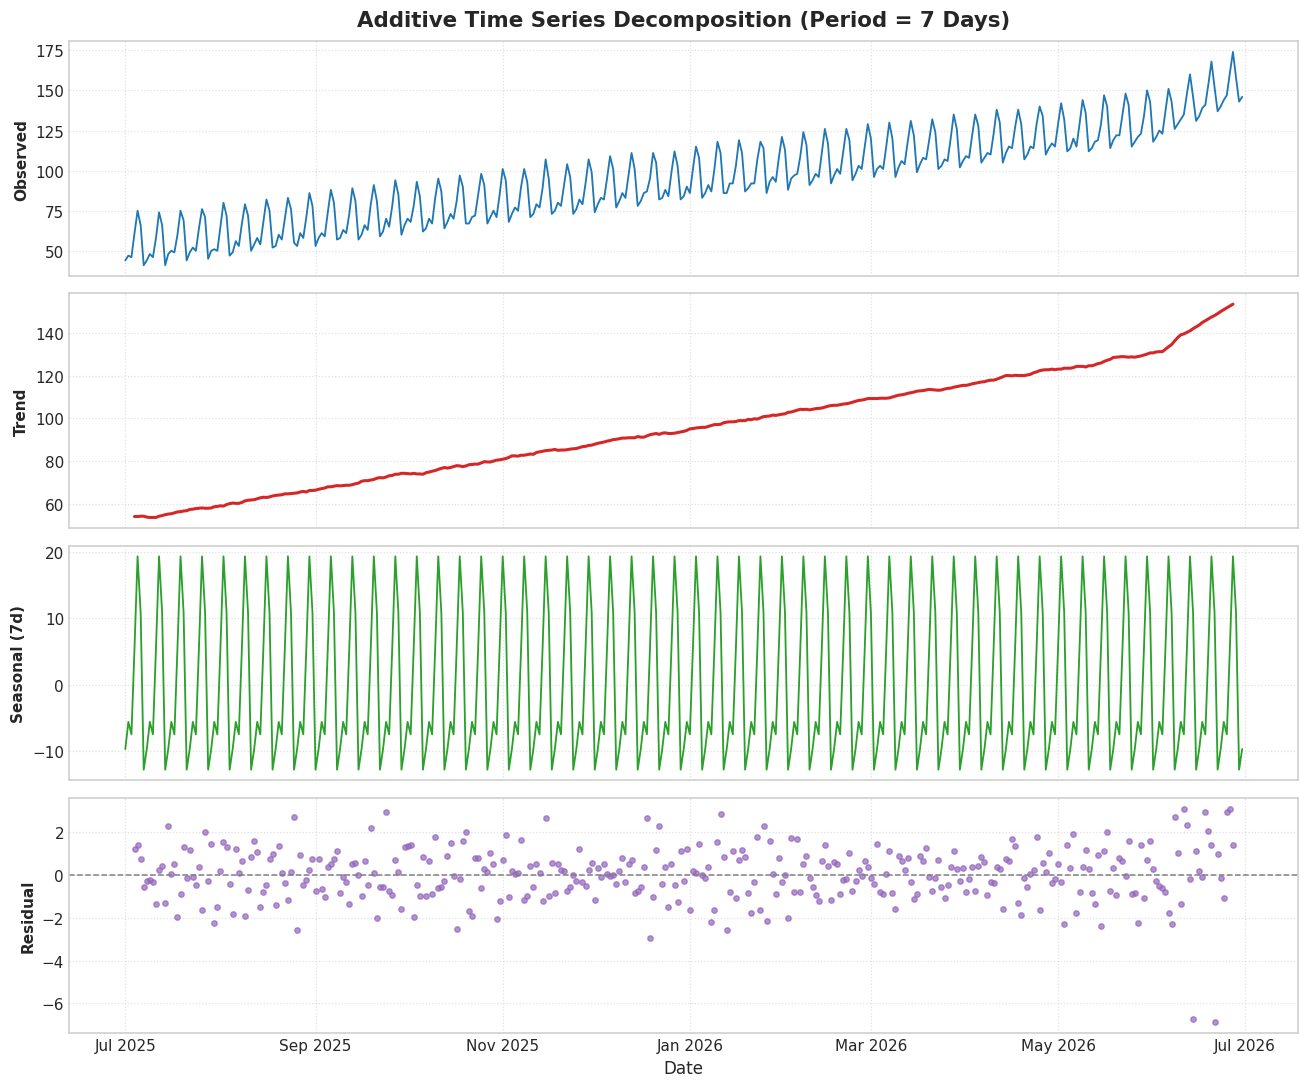

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df.index, df['demand'], color='#1f77b4', lw=1.2)
axes[0].set_ylabel('Observed', fontweight='semibold')
axes[0].set_title('Additive Time Series Decomposition (Period = 7 Days)', fontsize=14, fontweight='bold', pad=10)

axes[1].plot(df.index, trend, color='#d62728', lw=2)
axes[1].set_ylabel('Trend', fontweight='semibold')

axes[2].plot(df.index, seasonal, color='#2ca02c', lw=1.2)
axes[2].set_ylabel('Seasonal (7d)', fontweight='semibold')

axes[3].scatter(df.index, residual, color='#9467bd', s=12, alpha=0.7)
axes[3].axhline(0, color='gray', linestyle='--', lw=1)
axes[3].set_ylabel('Residual', fontweight='semibold')
axes[3].set_xlabel('Date', fontsize=11)

for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

## 4. Stationarity Analysis & Augmented Dickey-Fuller (ADF) Test

A stationary process has constant mean, variance, and autocorrelation structure over time. Most ARIMA models require stationarity.

We test the null hypothesis:
- $H_0$: The series has a unit root (non-stationary).
- $H_1$: The series has no unit root (stationary).

If $p$-value $< 0.05$, we reject $H_0$ and conclude that the series is stationary.

In [6]:
def test_stationarity(timeseries, title='Series'):
    result = adfuller(timeseries.dropna(), autolag='AIC')
    output = pd.Series({
        'ADF Test Statistic': round(result[0], 4),
        'p-value': round(result[1], 6),
        'Lags Used': int(result[2]),
        'Number of Observations': int(result[3]),
        'Critical Value (1%)': round(result[4]['1%'], 4),
        'Critical Value (5%)': round(result[4]['5%'], 4),
        'Critical Value (10%)': round(result[4]['10%'], 4),
        'Is Stationary (p < 0.05)': bool(result[1] < 0.05)
    }, name=title)
    return output

raw_adf = test_stationarity(df['demand'], title='Raw Demand')
print(raw_adf)

ADF Test Statistic            1.8697
p-value                     0.998478
Lags Used                         15
Number of Observations           349
Critical Value (1%)          -3.4492
Critical Value (5%)          -2.8699
Critical Value (10%)         -2.5712
Is Stationary (p < 0.05)       False
Name: Raw Demand, dtype: object


### Differencing Transformation

Because the raw demand series is non-stationary ($p > 0.05$ due to upward trend), we apply first-order differencing:
$$
\Delta Y_t = Y_t - Y_{t-1}
$$
and re-evaluate the ADF test.

                         Raw Demand First-Differenced Demand
ADF Test Statistic           1.8697                  -2.4151
p-value                    0.998478                 0.137513
Lags Used                        15                       14
Number of Observations          349                      349
Critical Value (1%)         -3.4492                  -3.4492
Critical Value (5%)         -2.8699                  -2.8699
Critical Value (10%)        -2.5712                  -2.5712
Is Stationary (p < 0.05)      False                    False


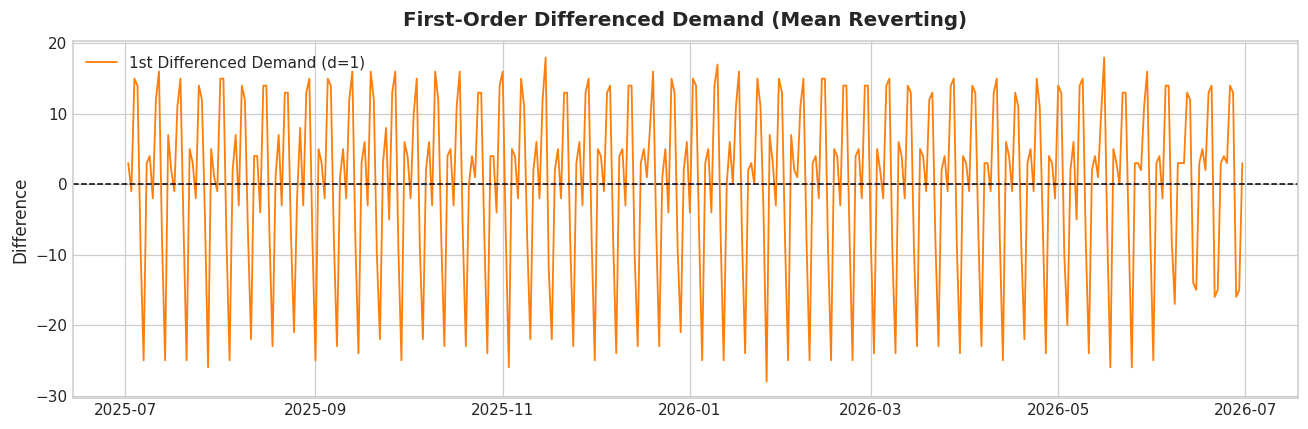

In [7]:
diff_1 = df['demand'].diff().dropna()
diff_adf = test_stationarity(diff_1, title='First-Differenced Demand')

adf_comparison = pd.concat([raw_adf, diff_adf], axis=1)
print(adf_comparison)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(diff_1.index, diff_1, color='#ff7f0e', lw=1.2, label='1st Differenced Demand (d=1)')
ax.axhline(0, color='black', linestyle='--', lw=1)
ax.set_title('First-Order Differenced Demand (Mean Reverting)', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Difference', fontsize=11)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

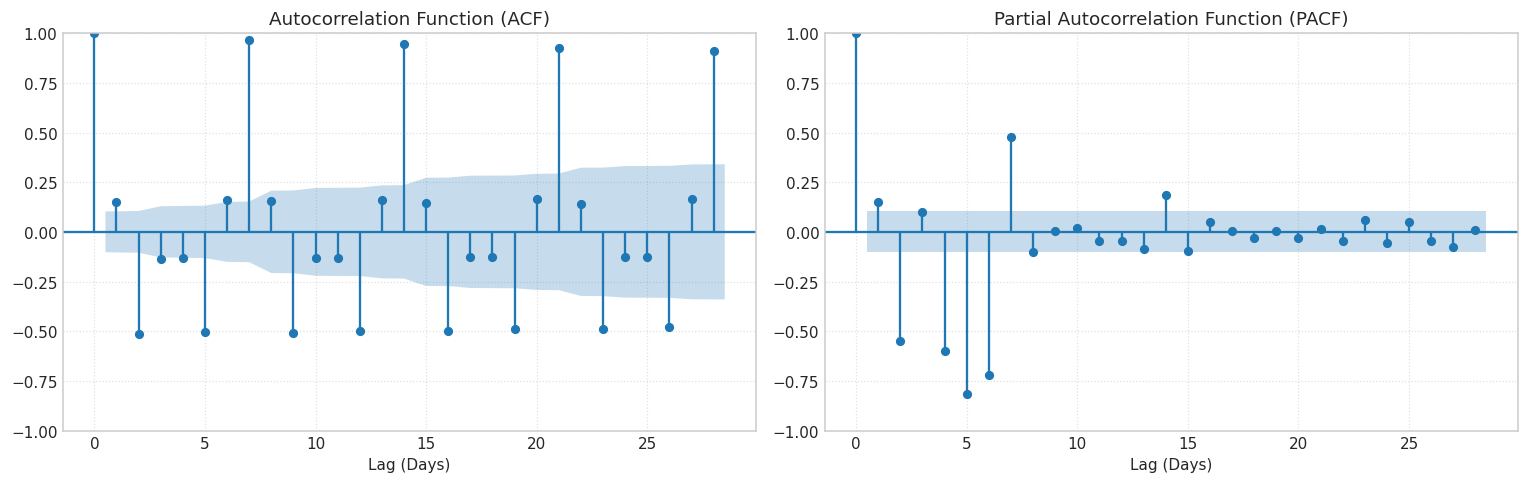

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
plot_acf(diff_1, lags=28, ax=ax1, title='Autocorrelation Function (ACF)')
plot_pacf(diff_1, lags=28, ax=ax2, title='Partial Autocorrelation Function (PACF)', method='ywm')

for ax in (ax1, ax2):
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlabel('Lag (Days)')
plt.tight_layout()
plt.show()

## 5. Temporal Train-Test Split (30-Day Holdout)

To prevent data leakage in time-series forecasting, we split chronologically:
- **Training Set**: 2025-07-01 to 2026-05-31 (335 observations)
- **Holdout Test Set**: 2026-06-01 to 2026-06-30 (30 observations)

Train set: 335 days (2025-07-01 to 2026-05-31)
Holdout test set: 30 days (2026-06-01 to 2026-06-30)


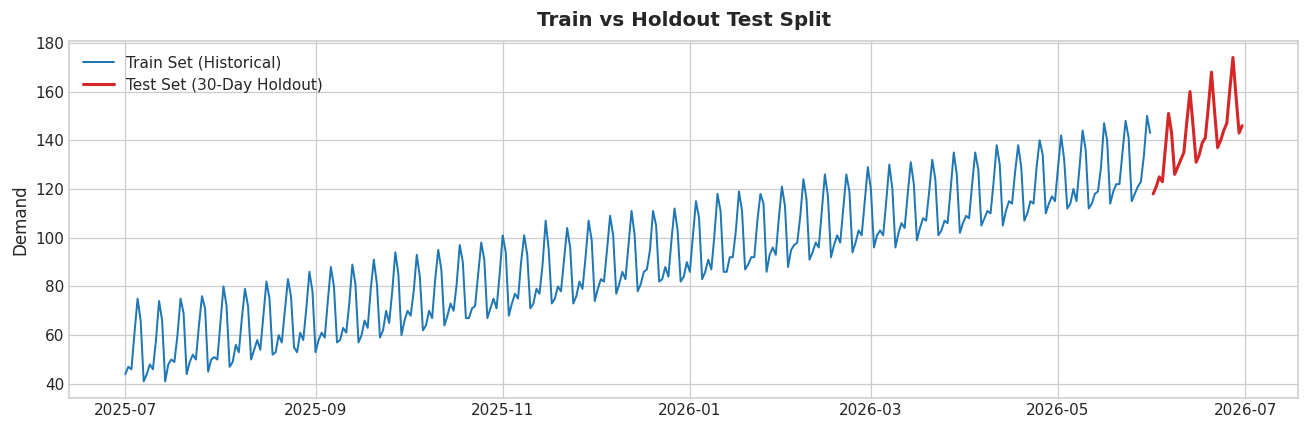

In [9]:
holdout_days = 30
train_df = df.iloc[:-holdout_days].copy()
test_df = df.iloc[-holdout_days:].copy()

print(f'Train set: {len(train_df)} days ({train_df.index.min().strftime("%Y-%m-%d")} to {train_df.index.max().strftime("%Y-%m-%d")})')
print(f'Holdout test set: {len(test_df)} days ({test_df.index.min().strftime("%Y-%m-%d")} to {test_df.index.max().strftime("%Y-%m-%d")})')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_df.index, train_df['demand'], label='Train Set (Historical)', color='#1f77b4', lw=1.3)
ax.plot(test_df.index, test_df['demand'], label='Test Set (30-Day Holdout)', color='#d62728', lw=2)
ax.set_title('Train vs Holdout Test Split', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Demand', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

## 6. SARIMA / SARIMAX Modeling & Hyperparameter Search

We formulate a Seasonal Autoregressive Integrated Moving Average model with Exogenous Regressors:
$$
\text{SARIMAX}(p, d, q) \times (P, D, Q)_s + \beta X_t
$$
with seasonal period $s = 7$ (weekly cycle). We select the optimal order via Akaike Information Criterion (AIC).

In [10]:
import itertools

p_vals = [0, 1, 2]
d_vals = [1]
q_vals = [0, 1, 2]
P_vals = [0, 1]
D_vals = [1]
Q_vals = [0, 1]
s = 7

best_aic = float('inf')
best_order = None
best_seasonal = None
results_list = []

exog_train = train_df[['marketing_event', 'holiday']]

for p, d, q in itertools.product(p_vals, d_vals, q_vals):
    for P, D, Q in itertools.product(P_vals, D_vals, Q_vals):
        try:
            model = SARIMAX(
                train_df['demand'],
                order=(p, d, q),
                seasonal_order=(P, D, Q, s),
                exog=exog_train,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = model.fit(disp=False, maxiter=50)
            results_list.append({
                'order': (p, d, q),
                'seasonal_order': (P, D, Q, s),
                'aic': res.aic,
                'bic': res.bic
            })
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = (p, d, q)
                best_seasonal = (P, D, Q, s)
        except:
            continue

search_df = pd.DataFrame(results_list).sort_values('aic').reset_index(drop=True)
print('Top 5 SARIMAX Models by AIC:')
print(search_df.head(5))
print(f'\nSelected Best Order: {best_order} x {best_seasonal} with AIC = {best_aic:.2f}')

C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\stat

C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


...

C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


C:\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


C:\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Top 5 SARIMAX Models by AIC:
       order seasonal_order          aic          bic
0  (0, 1, 2)   (0, 1, 1, 7)  1040.669980  1063.223391
1  (0, 1, 1)   (0, 1, 1, 7)  1041.026795  1059.837052
2  (1, 1, 2)   (0, 1, 1, 7)  1042.299869  1068.612181
3  (1, 1, 1)   (0, 1, 1, 7)  1043.004020  1065.576328
4  (2, 1, 2)   (0, 1, 1, 7)  1044.191973  1074.263187

Selected Best Order: (0, 1, 2) x (0, 1, 1, 7) with AIC = 1040.67


C:\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [11]:
sarimax_model = SARIMAX(
    train_df['demand'],
    order=best_order,
    seasonal_order=best_seasonal,
    exog=exog_train,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fitted = sarimax_model.fit(disp=False)
print(sarimax_fitted.summary().tables[1])

C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
marketing_event     0.7411      0.601      1.233      0.218      -0.437       1.919
holiday            -0.9606      0.618     -1.554      0.120      -2.172       0.251
ma.L1              -0.9870     56.338     -0.018      0.986    -111.408     109.434
ma.L2              -0.0130      0.726     -0.018      0.986      -1.436       1.410
ma.S.L7            -0.9823      0.072    -13.623      0.000      -1.124      -0.841
sigma2              1.3858     78.073      0.018      0.986    -151.635     154.407


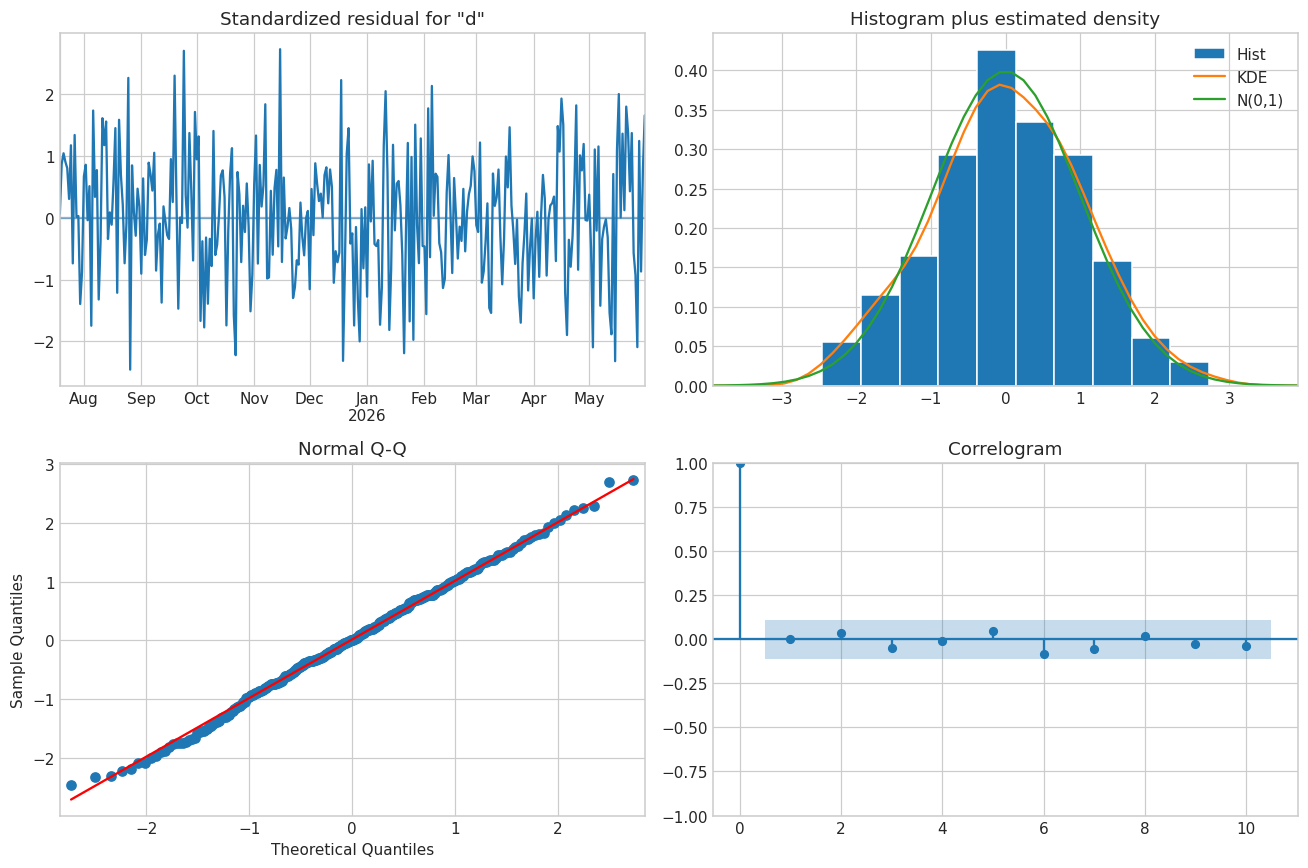

In [12]:
fig = sarimax_fitted.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()